In [1]:
import cv2
import numpy as np
import random
import math
from matplotlib import pyplot as plt

In [77]:
# Process image HSV
def process_image(IMAGE_FILE):    
    # Crop an image
    top = 300; bottom = 1900
    left = 480; right = 3425
    img_maze = cv2.imread(IMAGE_FILE)[top:bottom, left:right]
    
    # Masking the image
    thresh = 128
    maxval = 255
    img_hsv = cv2.cvtColor(img_maze, cv2.COLOR_BGR2HSV)    
    hsv_mask = cv2.inRange(img_hsv, (4,38,101), (27,255, 255))
    _, threshed = cv2.threshold(hsv_mask, thresh, maxval, cv2.THRESH_BINARY)
    
    # Removing peper noise
    kernel_size = 5
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    threshed = cv2.dilate(threshed, kernel, iterations = 3)
    
    # Thicken obstacles
    kernel_size = 3
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    threshed = cv2.erode(threshed, kernel, iterations = 21)
    
    # Removing peper noise
    kernel_size = 7
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    threshed = cv2.dilate(threshed, kernel, iterations = 3)
    
    # Convert it back to rgb
    threshed_3_channel = cv2.cvtColor(threshed, cv2.COLOR_GRAY2BGR)
    return threshed_3_channel

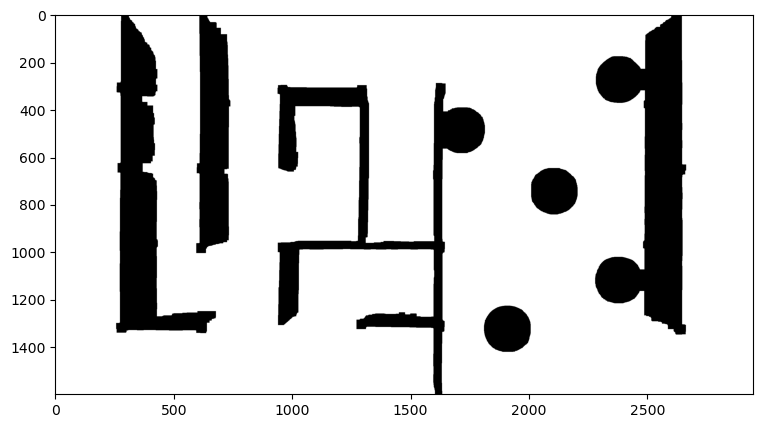

In [78]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMAGE_FILE = "obstacle.jpeg"
processed_img = process_image(IMAGE_FILE)

plt.figure(figsize = (9,5))
plt.imshow(processed_img)
plt.show()

# RRT/ RRT* approach


In [79]:
class treeNode:
    def __init__(self, node_id, x, y, cost):
        self.x = x
        self.y = y
        self.cost = cost
        self.parent = None
    
    def get_point(self):
        return (self.x, self.y)

class RRT:
    def __init__(self):
        self.nodes = {}
        self.edges = {}

    def add_node(self, node_id, x, y, cost):
        if node_id not in self.nodes:
            self.nodes[node_id] = treeNode(node_id, x, y, cost)
            self.edges[node_id] = {}
        pass

    def add_edge(self, node_id1, node_id2, weight):
        if node_id1 in self.nodes and node_id2 in self.nodes:
            self.edges[node_id1][node_id2] = weight
            self.edges[node_id2][node_id1] = weight
            self.get_nodes()[node_id2].parent = node_id1
        pass

    def remove_edge(self, node_id1, node_id2):
        if node_id1 in self.edges and node_id2 in self.edges[node_id1]:
            del self.edges[node_id1][node_id2]
            del self.edges[node_id2][node_id1]
            self.get_nodes()[node_id2].parent = None
        pass
    
    def get_nodes(self):
        return self.nodes
    
    def get_edge_weight(self, node_id1, node_id2):
        if node_id1 in self.edges and node_id2 in self.edges[node_id1]:
            return self.edges[node_id1][node_id2]
        return None

In [80]:
class Node:
    def __init__(self, node_id, x, y):
        self.id = node_id
        self.x = x
        self.y = y
    
    def get_point(self):
        return (self.x,self.y)
    
    def get_ID(self):
        return self.id

class Graph:
    def __init__(self):
        self.nodes = {}
        self.edges = {}

    def add_node(self, node_id, x, y):
        if node_id not in self.nodes:
            self.nodes[node_id] = Node(node_id, x, y)
            self.edges[node_id] = {}
        pass

    def add_edge(self, node_id1, node_id2, weight):
        if node_id1 in self.nodes and node_id2 in self.nodes:
            self.edges[node_id1][node_id2] = weight
            self.edges[node_id2][node_id1] = weight
        pass

    def remove_edge(self, node_id1, node_id2):
        if node_id1 in self.edges and node_id2 in self.edges[node_id1]:
            del self.edges[node_id1][node_id2]
            del self.edges[node_id2][node_id1]
        pass
    
    def get_nodes(self):
        return self.nodes
    
    def get_edge_weight(self, node_id1, node_id2):
        if node_id1 in self.edges and node_id2 in self.edges[node_id1]:
            return self.edges[node_id1][node_id2]
        return None 

In [81]:
def is_free(pixel):
    return (pixel[0] == 255 and pixel[1] == 255 and pixel[2] == 255)

# This is a useful function which you may choose to impliment and use 
# Given a random point it extends the tree by either the step distance or the cartesian distance
def calculate_new_tree_point(x_closest, y_closest, x, y, step):
    x1, y1 = (x_closest, y_closest)
    x2, y2 = (x, y)
    distance = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
    d = step   
    t = d / distance
    
    if distance <= d:
        return x2, y2, distance
    
    xx = int(x1 * (1 - t) + x2 * t)
    yy = int(y1 * (1 - t) + y2 * t)
    return (xx, yy, d)
       
# This is a useful function which you may choose to impliment and use 
# It finds and returns the closest node to a point on the image
def find_closest_node_rrt(tree, target_x, target_y):
    min_node_id = -2
    min_dist = float('inf')
    for node_id in tree.get_nodes():
        x, y = tree.get_nodes()[node_id].get_point()
        distance = np.sqrt((x - target_x) ** 2 + (y - target_y) ** 2)
        if distance < min_dist:
            min_dist = distance
            min_node_id = node_id
    return min_dist, min_node_id


def no_collision(image, x1, y1, x2, y2):
    # Code by chatGPT
    # Description: Incrementally check the line along 2 coordinates
    # Date: July 30 2024
    line_iter = np.linspace(0, 1, int(np.sqrt((x2 - x1)**2 + (y2 - y1)**2)))
    for t in line_iter:
        x = int(x1 * (1 - t) + x2 * t)
        y = int(y1 * (1 - t) + y2 * t)  
        pixel = image[x, y]
        if not is_free(pixel):
            return False
    return True

def find_nearby_nodes(tree, target_x, target_y, radius):
    nodes = []
    for node_id in tree.get_nodes():
        x, y = tree.get_nodes()[node_id].get_point()
        distance = np.sqrt((x - target_x) ** 2 + (y - target_y) ** 2)
        if distance < radius:
            nodes.append((distance, node_id))
    return nodes

In [82]:
# Convert cell coordinates to pixel coordinate 
# Initialise
bfs_image = processed_img.copy()
bfs_graph = Graph()
node_id = 0


# Maze size
maze_width = bfs_image.shape[1]
maze_height = bfs_image.shape[0]

# Cell size
rows = 5
columns = 9
cell_width = maze_width // columns
cell_height = maze_height // rows

# Map ratio
real_size = 250
ratio = (cell_width + cell_height) / (2 * real_size)

# Generate nodes
for i in range(rows):
    for j in range(columns):        
        x = cell_height * i + cell_height // 2
        y = cell_width * j + cell_width // 2
        bfs_graph.add_node(node_id, x, y)
        node_id += 1

# Find the coordinate
cell_x = 0
cell_y = 0
cell_id_start = cell_x * columns + cell_y
x_start, y_start = bfs_graph.get_nodes()[cell_id_start].get_point()

end_x = 0
end_y = 8
cell_id_end = end_x * columns + end_y
x_end, y_end = bfs_graph.get_nodes()[cell_id_end].get_point()

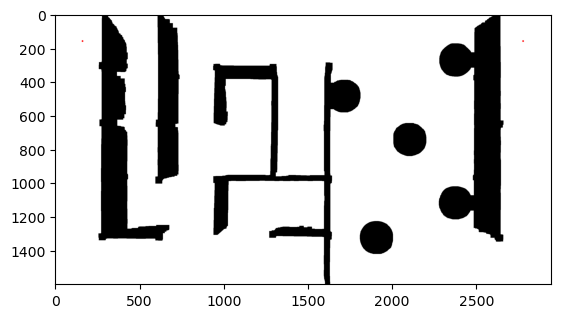

In [83]:
# Display nodes (optional)
cv2.circle(bfs_image, (y_start, x_start), 5, (255, 0, 0), -1)
cv2.circle(bfs_image, (y_end, x_end), 5, (255, 0, 0), -1)

# Display Resulting Image
plt.imshow(bfs_image)
plt.show()

In [84]:
def dijkstra(graph, start_id, end_id):
    dist = {node: float('inf') for node in graph.nodes}
    pred = {node: None for node in graph.nodes}
    dist[start_id] = 0
    
    unvisited_nodes = set(graph.nodes)
    while unvisited_nodes:
        min_node = min(unvisited_nodes, key=lambda node: dist[node])
        unvisited_nodes.remove(min_node)
        for neighbor, weight in graph.edges[min_node].items():
            new_dist = dist[min_node] + weight
            if new_dist < dist[neighbor]:
                dist[neighbor] = new_dist
                pred[neighbor] = min_node
    
    path = []
    current = end_id
    while current is not None:
        path.append(current)
        current = pred[current]
    path.reverse()
    total_cost = dist[end_id]

    return (path, total_cost)

0 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 4 4 4 4 4 4 4 4 4 4 5 5 5 5 5 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 7 7 7 7 7 7 7 8 8 8 8 8 8 8 8 9 9 9 10 10 10 10 10 11 12 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 14 14 14 14 14 14 14 14 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 17 17 17 17 17 17 17 17 17 17 17 17 17 17 17 17 17 17 17 17 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 19 19 19 19 19 19 19 19 19 19 19 19 19 20 20 20 20 21 21 21 21 21 21 21 21 21 21 21 21 21 21 21 21 21 21 21 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 22 23 23 23 23 23 23 23 23 23 23 23 23 23 23 23 23 23 23 23 23 23 23 23 23 23 23 23 23 23 23 23 23 23 23 23 23 23 23 23 23 23 23 23 23 23 24 24 24 24 24 24 24 24 2

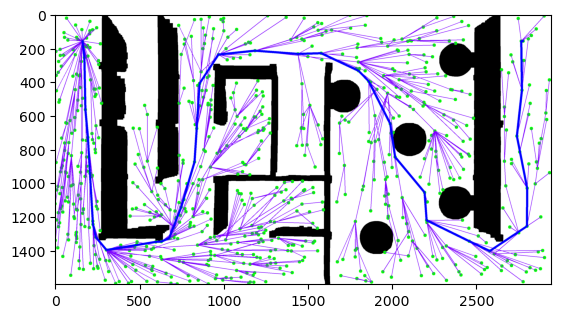

In [85]:
# Initialise the RRT
rrt_image = processed_img.copy()
rrt_graph = RRT()
random.seed(42)

debug = Graph()
idd = 0

# Intialise variables
iterations = 1000
new_id = 0
goal_id = iterations + 1

max_connection_range = (cell_width + cell_height) // 2
goal_radius = 20
step = cell_width

# Initialise RRT
rrt_graph.add_node(-1, x_start, y_start, 0)
# print(x_start, y_start)

# Loop for RRT*
beta = 0.0
i = 0
while i < iterations:
    print(i, end=" ")
    x = random.randint(0, maze_height - 1)
    y = random.randint(0, maze_width - 1)
    
    if (random.uniform(0, 1) < beta):
        x, y = (x_end, y_end)
    
    # Find closest node
    closest_distance, q_near = find_closest_node_rrt(rrt_graph, x, y)
    x_closest, y_closest = rrt_graph.get_nodes()[q_near].get_point()
    x_new, y_new, _ = calculate_new_tree_point(x_closest, y_closest, x, y, step)
    
#     cv2.circle(rrt_image, (y_new, x_new), 10, (255, 0, 255), -1)
    
#     debug.add_node(idd, x, y)
#     idd += 1
#     i += 1
    
#     # No collision
#     print(x_closest, y_closest, x_new, y_new)
    if no_collision(rrt_image, x_closest, y_closest, x_new, y_new):
        
        
        # Find in neighbourhood
        nearby_nodes = find_nearby_nodes(rrt_graph, x_new, y_new, max_connection_range) 
        
        # Find best nodes in neighbourhood
        best_node = None
        min_cost = float('inf')
        for d, node in nearby_nodes:
            x_near, y_near = rrt_graph.get_nodes()[node].get_point()
            if no_collision(rrt_image, x_new, y_new, x_near, y_near):
                cost = rrt_graph.get_nodes()[node].cost + d
                if cost < min_cost:
                    best_node = node
                    min_cost = cost
                    closest_distance = d
        
        # Add new node
        rrt_graph.add_node(new_id, x_new, y_new, min_cost)
        rrt_graph.add_edge(best_node, new_id, closest_distance)
        
        # Rewire
        for d, node in nearby_nodes:
            if node == best_node:
                continue
            
            x_near, y_near = rrt_graph.get_nodes()[node].get_point()
            if no_collision(rrt_image, x_new, y_new, x_near, y_near):
                cost = rrt_graph.get_nodes()[new_id].cost + d
                if cost < rrt_graph.get_nodes()[node].cost:
                    rrt_graph.remove_edge(rrt_graph.get_nodes()[node].parent, node)
                    rrt_graph.add_edge(new_id, node, d)
                    rrt_graph.get_nodes()[node].cost = cost
                    
        new_id += 1
        i += 1
        
        dist = np.sqrt((x_end - x_new) ** 2 + (y_end - y_new) ** 2)
        if  dist < goal_radius:
            c = rrt_graph.get_nodes()[new_id - 1].cost + dist
            rrt_graph.add_node(goal_id, x_end, y_end, c)
            rrt_graph.add_edge(new_id - 1, goal_id, dist)
            break 

# Display tree nodes
dictionary = debug.get_nodes()
for node_id in dictionary:
    x, y = dictionary[node_id].get_point()
#     print(x, y)
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 2
    color = (255, 0, 0)
    thickness = 1
    cv2.circle(rrt_image, (y, x), 10, (255, 0, 0), -1)
    cv2.putText(rrt_image, str(node_id), (y, x), font, font_scale, color, thickness, cv2.LINE_AA)  
    
# Display tree nodes
dictionary = rrt_graph.get_nodes()
for node_id in dictionary:
    x, y = dictionary[node_id].get_point()
    cv2.circle(rrt_image, (y, x), 10, (0, 255, 0), -1)
    

# Display edges
dictionary = rrt_graph.get_nodes()
for node_id1 in dictionary:
    for node_id2 in dictionary:
        if rrt_graph.get_edge_weight(node_id1, node_id2) != None:
            x1, y1 = dictionary[node_id1].get_point()
            x2, y2 = dictionary[node_id2].get_point()
            cv2.line(rrt_image, (y1, x1), (y2, x2), (125, 0, 255), 2)

# Display route
path, cost = dijkstra(rrt_graph, -1, goal_id)
for i in range(len(path) - 1):
    node_id1 = path[i]
    node_id2 = path[i + 1]
    
    x1, y1 = rrt_graph.nodes[node_id1].get_point()
    x2, y2 = rrt_graph.nodes[node_id2].get_point()
    
    cv2.line(rrt_image, (y1, x1), (y2, x2), (0, 0, 255), 12)
print(cost)

# Display Resulting Image
plt.imshow(rrt_image)
plt.show()

# BFS grid approach

In [ ]:
# Initialise
bfs_image = processed_img.copy()
bfs_graph = Graph()
node_id = 0

# Maze size
maze_width = bfs_image.shape[1]
maze_height = bfs_image.shape[0]

# Cell size
rows = 5
columns = 9
cell_width = maze_width // columns
cell_height = maze_height // rows

# Map ratio
real_size = 250
ratio = (cell_width + cell_height) / (2 * real_size)

# Generate nodes
for i in range(rows):
    for j in range(columns):        
        x = cell_height * i + cell_height // 2
        y = cell_width * j + cell_width // 2
        bfs_graph.add_node(node_id, x, y)
        node_id += 1

# Display nodes  
dictionary = bfs_graph.get_nodes()
for node_id in dictionary:
    x, y = dictionary[node_id].get_point()
    # Printing
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 2
    color = (255, 0, 0)
    thickness = 1
    cv2.circle(bfs_image, (y, x), 5, (255, 0, 0), -1)
    cv2.putText(bfs_image, str(node_id), (y, x), font, font_scale, color, thickness, cv2.LINE_AA)  


# Display Resulting Image
plt.imshow(bfs_image)
plt.show()

In [ ]:
def path_clear(image, x1, y1, x2, y2):
    line_iter = np.linspace(0, 1, int(np.sqrt((x2 - x1)**2 + (y2 - y1)**2)))
    for t in line_iter:
        x = int(x1 * (1 - t) + x2 * t)
        y = int(y1 * (1 - t) + y2 * t)
        pixel = image[x, y]
        if (pixel[0] < 255 and pixel[1] < 255 and pixel[2] < 255):
            return False
    return True

In [ ]:
# Generate edges
start = 0
end = rows * columns
# end = 2

# Horizontal
for i in range(start, end):
    if (i + 1) % (columns) == 0:
        continue
        
    node_id1 = i
    node_id2 = node_id1 + 1
    x1, y1 = dictionary[node_id1].get_point()
    x2, y2 = dictionary[node_id2].get_point()
    if path_clear(bfs_image, x1, y1, x2, y2):
        bfs_graph.add_edge(node_id1, node_id2, 1)

# Vertical
for i in range(columns):
    for j in range(rows - 1):
        node_id1 = i + j * columns
        node_id2 = node_id1 + columns
        x1, y1 = dictionary[node_id1].get_point()
        x2, y2 = dictionary[node_id2].get_point()
        if path_clear(bfs_image, x1, y1, x2, y2):
            bfs_graph.add_edge(node_id1, node_id2, 1)


print(bfs_graph.edges)

# Display edges
for node_id1 in dictionary:
    for node_id2 in dictionary:
        if bfs_graph.get_edge_weight(node_id1, node_id2) != None:
            x1, y1 = dictionary[node_id1].get_point()
            x2, y2 = dictionary[node_id2].get_point()
            cv2.line(bfs_image, (y1, x1), (y2, x2), (0, 255, 0), 4)

# Display Resulting Image
plt.imshow(bfs_image)
plt.show()